# Auditoría reproducible del dataset

Este notebook reproduce a demanda los controles y conteos descritos en [`docs/dataset-audit.md`](../docs/dataset-audit.md). Por defecto analiza `dataset/train.csv` y `dataset/train/`. Para auditar otro corte, ajuste la celda **Configuración** y ejecute **Run All**.

Las salidas no se versionan para evitar confundir resultados históricos con el estado vigente del dataset.

In [1]:
from collections import Counter
from hashlib import sha256
from pathlib import Path
import json
import re

import matplotlib.pyplot as plt
import pandas as pd
import soundfile as sf
from IPython.display import display

## Configuración

`LABEL_COLUMNS = None` considera etiquetas todas las columnas excepto `FILENAME_COLUMN`. `REPORT_PATH = None` evita escrituras; indique una ruta si desea exportar el resumen JSON.

In [2]:
project_root = Path.cwd().resolve()
if not (project_root / "pyproject.toml").exists():
    candidate = project_root.parent
    if (candidate / "pyproject.toml").exists():
        project_root = candidate

DATASET_ROOT = project_root / "dataset"
METADATA_PATH = DATASET_ROOT / "train.csv"
AUDIO_DIRECTORY = DATASET_ROOT / "train"
AUDIO_GLOB = "*.wav"
FILENAME_COLUMN = "filename"
LABEL_COLUMNS = None

# Cada expresión debe tener exactamente un grupo de captura.
SEGMENT_PATTERN = re.compile(r"^(.*)_\d+_\d+\.wav$")
SITE_PATTERN = re.compile(r"^INCT([^_]+)")  # Use None si el dataset no codifica sitios.

MAIN_MIN_RECORDINGS = 10
EXPLORATORY_MIN_RECORDINGS = 3
MIN_RECORDINGS_BY_SPLIT = {"train": 8, "validation": 2}
AUDIT_AUDIO_HEADERS = True
REPORT_PATH = None

print(f"Metadatos: {METADATA_PATH}")
print(f"Audios:    {AUDIO_DIRECTORY}")

Metadatos: /Users/hugo.angeles/Code/utec-deeplearning-lab01/dataset/train.csv
Audios:    /Users/hugo.angeles/Code/utec-deeplearning-lab01/dataset/train


## Funciones auxiliares

In [3]:
def file_sha256(path: Path, chunk_size: int = 1024 * 1024) -> str:
    digest = sha256()
    with path.open("rb") as stream:
        for chunk in iter(lambda: stream.read(chunk_size), b""):
            digest.update(chunk)
    return digest.hexdigest()


def extract_group(values: pd.Series, pattern: re.Pattern[str]) -> tuple[pd.Series, pd.Series]:
    extracted = values.str.extract(pattern, expand=False)
    if isinstance(extracted, pd.DataFrame):
        if extracted.shape[1] != 1:
            raise ValueError("La expresión debe tener exactamente un grupo de captura")
        extracted = extracted.iloc[:, 0]
    return extracted, extracted.notna()


def label_category(positive_recordings: int) -> str:
    if positive_recordings >= MAIN_MIN_RECORDINGS:
        return "principal"
    if positive_recordings >= EXPLORATORY_MIN_RECORDINGS:
        return "exploratoria"
    if positive_recordings > 0:
        return "evidencia insuficiente"
    return "sin evidencia"


def inspect_audio_headers(paths: list[Path]) -> tuple[pd.DataFrame, pd.DataFrame]:
    properties = Counter()
    errors = []
    for path in paths:
        try:
            info = sf.info(path)
            key = (info.format, info.subtype, info.samplerate, info.channels, info.frames)
            properties[key] += 1
        except Exception as error:  # noqa: BLE001
            errors.append({
                "filename": path.name,
                "error_type": type(error).__name__,
                "message": str(error),
            })

    rows = []
    for (audio_format, subtype, sample_rate, channels, frames), files in properties.items():
        rows.append({
            "format": audio_format,
            "subtype": subtype,
            "sample_rate": sample_rate,
            "channels": channels,
            "frames": frames,
            "duration_seconds": frames / sample_rate,
            "files": files,
        })
    return pd.DataFrame(rows), pd.DataFrame(errors)

## Carga y contrato de metadatos

In [4]:
if not METADATA_PATH.is_file():
    raise FileNotFoundError(f"No existe el CSV: {METADATA_PATH}")
if not AUDIO_DIRECTORY.is_dir():
    raise FileNotFoundError(f"No existe el directorio de audios: {AUDIO_DIRECTORY}")

metadata = pd.read_csv(METADATA_PATH)
if FILENAME_COLUMN not in metadata.columns:
    raise ValueError(f"Falta la columna requerida: {FILENAME_COLUMN}")

label_columns = (
    list(LABEL_COLUMNS)
    if LABEL_COLUMNS is not None
    else [column for column in metadata.columns if column != FILENAME_COLUMN]
)
missing_labels = sorted(set(label_columns) - set(metadata.columns))
if missing_labels:
    raise ValueError(f"No existen las columnas de etiquetas: {missing_labels}")
if not label_columns:
    raise ValueError("No se seleccionó ninguna columna de etiqueta")

filenames = metadata[FILENAME_COLUMN].astype("string")
labels = metadata[label_columns]
recording_ids, valid_segment_name = extract_group(filenames, SEGMENT_PATTERN)

print(f"Filas: {len(metadata):,}")
print(f"Etiquetas: {len(label_columns):,}")
display(metadata.head())

Filas: 62,191
Etiquetas: 42


,filename,SPHSUR,BOABIS,SCIPER,DENNAH,LEPLAT,RHIICT,BOALEP,BOAFAB,PHYCUV,...,SCINAS,LEPNOT,ADEMAR,BOAALM,PHYDIS,RHIORN,LEPFLA,SCIRIZ,DENELE,SCIALT
0,INCT20955_20190909_050000_0_3.wav,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,INCT20955_20190909_050000_1_4.wav,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,INCT20955_20190909_050000_2_5.wav,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,INCT20955_20190909_050000_3_6.wav,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,INCT20955_20190909_050000_4_7.wav,1,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## Trazabilidad e integridad

La correspondencia se compara por nombre. Si `AUDIT_AUDIO_HEADERS` está activo, también se abre la cabecera de cada audio para agrupar sus propiedades técnicas y detectar archivos ilegibles.

In [5]:
audio_paths = sorted(AUDIO_DIRECTORY.glob(AUDIO_GLOB))
audio_names = {path.name for path in audio_paths}
csv_names = set(filenames.dropna())
nonbinary_cells = int((~labels.isin([0, 1]) & labels.notna()).sum().sum())

integrity = pd.DataFrame([
    {"control": "SHA-256 del CSV", "value": file_sha256(METADATA_PATH)},
    {"control": "Tamaño del CSV en bytes", "value": METADATA_PATH.stat().st_size},
    {"control": "Filas", "value": len(metadata)},
    {"control": "Columnas de etiquetas", "value": len(label_columns)},
    {"control": "Filas con algún nulo", "value": int(metadata.isna().any(axis=1).sum())},
    {"control": "Celdas de etiqueta no binarias", "value": nonbinary_cells},
    {"control": "Nombres duplicados", "value": int(filenames.duplicated().sum())},
    {"control": "Nombres fuera de SEGMENT_PATTERN", "value": int((~valid_segment_name).sum())},
    {"control": "Archivos encontrados", "value": len(audio_paths)},
    {"control": "Filas sin audio", "value": len(csv_names - audio_names)},
    {"control": "Audios sin fila", "value": len(audio_names - csv_names)},
])
display(integrity)

if csv_names - audio_names:
    display(pd.Series(sorted(csv_names - audio_names), name="filas_sin_audio").head(20))
if audio_names - csv_names:
    display(pd.Series(sorted(audio_names - csv_names), name="audios_sin_fila").head(20))
if (~valid_segment_name).any():
    display(filenames[~valid_segment_name].rename("nombres_no_reconocidos").head(20))

,control,value
0,SHA-256 del CSV,38df5d408d9bf621cc11f78ed4cd766be63a8406512c1e...
1,Tamaño del CSV en bytes,7358909
2,Filas,62191
3,Columnas de etiquetas,42
4,Filas con algún nulo,0
5,Celdas de etiqueta no binarias,0
6,Nombres duplicados,0
7,Nombres fuera de SEGMENT_PATTERN,0
8,Archivos encontrados,62191
9,Filas sin audio,0


In [6]:
if AUDIT_AUDIO_HEADERS:
    audio_properties, audio_errors = inspect_audio_headers(audio_paths)
    display(audio_properties.sort_values("files", ascending=False))
    print(f"Errores al abrir audios: {len(audio_errors):,}")
    if not audio_errors.empty:
        display(audio_errors.head(20))
else:
    audio_properties = pd.DataFrame()
    audio_errors = pd.DataFrame()
    print("Inspección de cabeceras omitida por configuración.")

,format,subtype,sample_rate,channels,frames,duration_seconds,files
0,WAV,PCM_16,22050,1,66150,3.0,62191


Errores al abrir audios: 0


## Grabaciones y sitios

Los conteos excluyen nombres que no cumplan `SEGMENT_PATTERN`. Una auditoría con fallos de extracción no debe aceptarse sin corregir la configuración o revisar esos nombres.

In [7]:
valid_rows = valid_segment_name
clips_per_recording = recording_ids[valid_rows].value_counts()
recording_summary = clips_per_recording.describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
).rename("clips_por_grabacion").to_frame()
recording_distribution = (
    clips_per_recording.value_counts()
    .sort_index()
    .rename_axis("clips")
    .rename("grabaciones")
    .to_frame()
)
display(recording_summary)
display(recording_distribution)

if SITE_PATTERN is not None:
    sites, valid_site = extract_group(recording_ids[valid_rows], SITE_PATTERN)
    site_data = pd.DataFrame({"site": sites, "recording_id": recording_ids[valid_rows]})
    site_summary = pd.concat([
        site_data["site"].value_counts().rename("clips"),
        site_data.drop_duplicates()["site"].value_counts().rename("recordings"),
    ], axis=1).fillna(0).astype(int).sort_index()
    site_summary["clip_percentage"] = 100 * site_summary["clips"] / valid_rows.sum()
    site_summary["recording_percentage"] = (
        100 * site_summary["recordings"] / recording_ids[valid_rows].nunique()
    )
    display(site_summary)
    print(f"Grabaciones sin sitio reconocido: {recording_ids[valid_rows][~valid_site].nunique():,}")
else:
    site_summary = pd.DataFrame()
    print("Distribución por sitio omitida por configuración.")

,clips_por_grabacion
count,1074.0
mean,57.905959
std,1.518909
min,26.0
25%,58.0
50%,58.0
75%,58.0
90%,58.0
95%,58.0
99%,58.0


,grabaciones
clips,
26,1
28,1
42,2
51,1
58,1069


,clips,recordings,clip_percentage,recording_percentage
site,,,,
17,13688,236,22.009616,21.973929
20955,18111,314,29.121577,29.236499
4,16240,280,26.113103,26.070764
41,14152,244,22.755704,22.718808


Grabaciones sin sitio reconocido: 0


## Distribución multietiqueta y soporte

,clips,percentage
positive_labels,,
0,22504,36.185300
1,12886,20.720040
2,10591,17.029795
3,8636,13.886254
4,5032,8.091203
5,1685,2.709395
6,664,1.067679
7,182,0.292647
8,11,0.017687


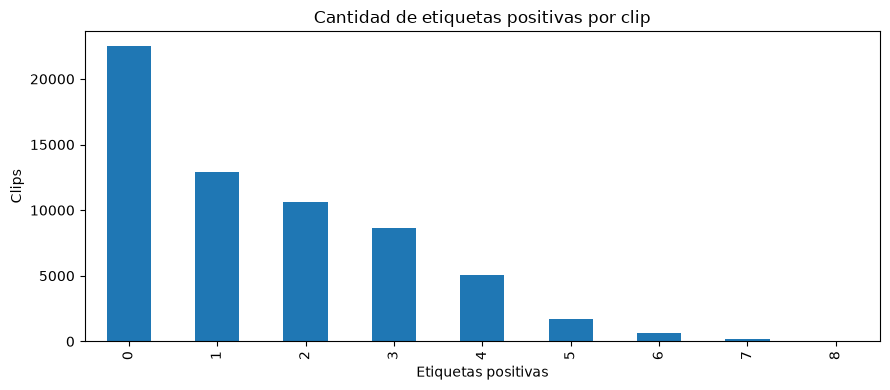

In [8]:
label_cardinality = labels.sum(axis=1)
cardinality_summary = (
    label_cardinality.value_counts()
    .sort_index()
    .rename_axis("positive_labels")
    .rename("clips")
    .to_frame()
)
cardinality_summary["percentage"] = 100 * cardinality_summary["clips"] / len(metadata)
display(cardinality_summary)

ax = cardinality_summary["clips"].plot.bar(
    figsize=(9, 4), title="Cantidad de etiquetas positivas por clip"
)
ax.set_xlabel("Etiquetas positivas")
ax.set_ylabel("Clips")
plt.tight_layout()
plt.show()

In [9]:
recording_presence = (
    labels.loc[valid_rows]
    .assign(recording_id=recording_ids[valid_rows].to_numpy())
    .groupby("recording_id")[label_columns]
    .max()
)
label_support = pd.DataFrame({
    "positive_clips": labels.sum().astype(int),
    "positive_recordings": recording_presence.sum().astype(int),
})
label_support["category"] = label_support["positive_recordings"].map(label_category)
label_support = label_support.sort_values(
    ["positive_recordings", "positive_clips"], ascending=False
)
display(label_support)
display(
    label_support["category"]
    .value_counts()
    .rename_axis("category")
    .rename("labels")
    .to_frame()
)

,positive_clips,positive_recordings,category
SPHSUR,13258,257,principal
BOABIS,10888,240,principal
DENMIN,6070,175,principal
PHYALB,5374,133,principal
BOAALB,3704,132,principal
BOAFAB,6438,128,principal
PHYCUV,4240,128,principal
LEPLAT,5244,127,principal
LEPPOD,6032,125,principal
PITAZU,4873,125,principal


,labels
category,
principal,31
evidencia insuficiente,5
exploratoria,4
sin evidencia,2


## Taxonomía activa y `out_of_scope_foreground`

La taxonomía principal se deriva de `MAIN_MIN_RECORDINGS`. Los clips con positivos originales pero sin positivos principales se contabilizan como `out_of_scope_foreground`; no se interpretan como fondo puro.

In [10]:
main_labels = label_support.index[label_support["category"].eq("principal")].tolist()
excluded_labels = [label for label in label_columns if label not in main_labels]
original_zero = labels.sum(axis=1).eq(0)
active_zero = labels[main_labels].sum(axis=1).eq(0)
out_of_scope_foreground = active_zero & ~original_zero
negative_summary = pd.DataFrame([
    {
        "measure": "Sin positivos originales",
        "clips": int(original_zero.sum()),
        "percentage": 100 * original_zero.mean(),
    },
    {
        "measure": "Sin positivos en la taxonomía principal",
        "clips": int(active_zero.sum()),
        "percentage": 100 * active_zero.mean(),
    },
    {
        "measure": "out_of_scope_foreground",
        "clips": int(out_of_scope_foreground.sum()),
        "percentage": 100 * out_of_scope_foreground.mean(),
    },
])
display(negative_summary)
print(f"Etiquetas principales ({len(main_labels)}): {main_labels}")
print(f"Etiquetas excluidas ({len(excluded_labels)}): {excluded_labels}")

,measure,clips,percentage
0,Sin positivos originales,22504,36.185300
1,Sin positivos en la taxonomía principal,22731,36.550305
2,out_of_scope_foreground,227,0.365005


Etiquetas principales (31): ['SPHSUR', 'BOABIS', 'DENMIN', 'PHYALB', 'BOAALB', 'BOAFAB', 'PHYCUV', 'LEPLAT', 'LEPPOD', 'PITAZU', 'DENNAN', 'SCIPER', 'SCIFUV', 'BOALUN', 'PHYDIS', 'BOAALM', 'PHYSAU', 'BOARAN', 'BOALEP', 'ELABIC', 'LEPFUS', 'LEPNOT', 'BOAPRA', 'LEPLAB', 'DENCRU', 'ELAMAT', 'DENNAH', 'PHYMAR', 'RHIICT', 'ADEMAR', 'PHYNAT']
Etiquetas excluidas (11): ['SCIFUS', 'AMEPIC', 'ADEDIP', 'LEPELE', 'RHISCI', 'SCINAS', 'RHIORN', 'LEPFLA', 'SCIRIZ', 'DENELE', 'SCIALT']


## Comprobaciones de aceptación y reporte

La factibilidad marginal no garantiza una asignación multietiqueta concreta: el generador de particiones todavía debe validar coocurrencias y cobertura después de asignar las grabaciones.

In [11]:
required_recordings = sum(MIN_RECORDINGS_BY_SPLIT.values())
checks = pd.DataFrame([
    {"check": "CSV sin filas nulas", "passed": not metadata.isna().any(axis=1).any()},
    {"check": "Etiquetas binarias", "passed": nonbinary_cells == 0},
    {"check": "Nombres únicos", "passed": not filenames.duplicated().any()},
    {"check": "Nombres segmentados reconocidos", "passed": valid_segment_name.all()},
    {"check": "Cada fila tiene audio", "passed": not (csv_names - audio_names)},
    {"check": "Cada audio tiene fila", "passed": not (audio_names - csv_names)},
    {
        "check": "Cabeceras legibles o inspección desactivada",
        "passed": not AUDIT_AUDIO_HEADERS or audio_errors.empty,
    },
    {
        "check": f"Principales con al menos {required_recordings} grabaciones",
        "passed": bool(main_labels) and bool(
            (label_support.loc[main_labels, "positive_recordings"] >= required_recordings).all()
        ),
    },
])
checks["status"] = checks["passed"].map({True: "OK", False: "REVISAR"})
display(checks[["check", "status"]])

audit_report = {
    "metadata_path": str(METADATA_PATH),
    "audio_directory": str(AUDIO_DIRECTORY),
    "metadata_sha256": file_sha256(METADATA_PATH),
    "rows": len(metadata),
    "label_columns": len(label_columns),
    "audio_files": len(audio_paths),
    "recordings": int(recording_ids[valid_rows].nunique()),
    "sites": None if SITE_PATTERN is None else int(site_summary.shape[0]),
    "main_labels": main_labels,
    "excluded_labels": excluded_labels,
    "clips_without_original_positives": int(original_zero.sum()),
    "clips_without_main_positives": int(active_zero.sum()),
    "out_of_scope_foreground": int(out_of_scope_foreground.sum()),
    "checks": {
        str(check): bool(passed)
        for check, passed in zip(checks["check"], checks["passed"], strict=True)
    },
}

if REPORT_PATH is not None:
    report_path = Path(REPORT_PATH)
    if not report_path.is_absolute():
        report_path = project_root / report_path
    report_path.parent.mkdir(parents=True, exist_ok=True)
    report_path.write_text(
        json.dumps(audit_report, indent=2, ensure_ascii=False), encoding="utf-8"
    )
    print(f"Reporte exportado a {report_path}")

audit_report

,check,status
0,CSV sin filas nulas,OK
1,Etiquetas binarias,OK
2,Nombres únicos,OK
3,Nombres segmentados reconocidos,OK
4,Cada fila tiene audio,OK
5,Cada audio tiene fila,OK
6,Cabeceras legibles o inspección desactivada,OK
7,Principales con al menos 10 grabaciones,OK


{'metadata_path': '/Users/hugo.angeles/Code/utec-deeplearning-lab01/dataset/train.csv',
 'audio_directory': '/Users/hugo.angeles/Code/utec-deeplearning-lab01/dataset/train',
 'metadata_sha256': '38df5d408d9bf621cc11f78ed4cd766be63a8406512c1eb4d611d98e4486d276',
 'rows': 62191,
 'label_columns': 42,
 'audio_files': 62191,
 'recordings': 1074,
 'sites': 4,
 'main_labels': ['SPHSUR',
  'BOABIS',
  'DENMIN',
  'PHYALB',
  'BOAALB',
  'BOAFAB',
  'PHYCUV',
  'LEPLAT',
  'LEPPOD',
  'PITAZU',
  'DENNAN',
  'SCIPER',
  'SCIFUV',
  'BOALUN',
  'PHYDIS',
  'BOAALM',
  'PHYSAU',
  'BOARAN',
  'BOALEP',
  'ELABIC',
  'LEPFUS',
  'LEPNOT',
  'BOAPRA',
  'LEPLAB',
  'DENCRU',
  'ELAMAT',
  'DENNAH',
  'PHYMAR',
  'RHIICT',
  'ADEMAR',
  'PHYNAT'],
 'excluded_labels': ['SCIFUS',
  'AMEPIC',
  'ADEDIP',
  'LEPELE',
  'RHISCI',
  'SCINAS',
  'RHIORN',
  'LEPFLA',
  'SCIRIZ',
  'DENELE',
  'SCIALT'],
 'clips_without_original_positives': 22504,
 'clips_without_main_positives': 22731,
 'out_of_scope_fore